## Homework 8  

Name: Acamaro

Comments for grader: I worked with Connor Hunt so code can be slightly similar to his.


## 1. Electronic capacitor
Consider the following simple model of an electronic capacitor,
consisting of two flat metal plates enclosed in a square metal box:

![ch9_exercise9.3.PNG](attachment:ch9_exercise9.3.PNG)

For simplicity let us model the system in two dimensions.  

**a)** Using the **Jacobi method**, write a program to calculate the electrostatic
potential in the box on a grid of $100\times100$ points, where the walls of
the box are at voltage zero and the two plates (which are of negligible
thickness) are at voltages $\pm1\,$V as shown.  Have your program calculate
the value of the potential at each grid point to a precision of
$10^{-6}\,$volts and then make a density plot of the result. Include a colorbar that shows the scale.

Hint: Notice that the capacitor plates are at fixed *voltage*, not
fixed charge, so this problem differs from examples we did in class.  In effect, the capacitor plates are part of the boundary
condition in this case: they behave the same way as the walls of the box,
with potentials that are fixed at a certain value and cannot change.

Solution converged in 251 iterations


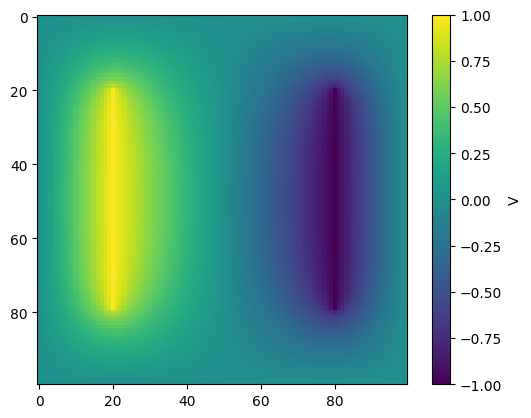

In [ ]:
#Type your code here
import numpy as np
import matplotlib.pyplot as plt

#Grid Parameters
N = 100
epsilon = 1e-6
# define grid spacing
a = 0.1/N # m

# Initialize Potential Array
solution = np.zeros([N,N],float)
# Start Initial Conditions!
solution[20:80, 20] = 1
solution[20:80, 80] = -1


def phi(i,j,V):
    omega  = 0.9
    return (1.0+omega)*(V[j, i+1]+V[j,i-1]+V[j+1,i]+V[j-1,i])/4 - omega*V[j,i]

# create logical convergence variable
converge = False

it = 0 # iteration counter
while converge == False:
    it += 1
    converge = True
    # calculate new solutions just on the interior points
    for j in range(1,N-1):
        for i in range(1,N-1):
            store = solution[j,i]
            solution[j,i] = phi(i,j,solution) # use the old solutions to calculate new solutions
            # Start Initial Conditions!
            solution[20:80, 20] = 1
            solution[20:80, 80] = -1
            if abs(solution[j,i]-store) > epsilon:
                converge = False

print ("Solution converged in {} iterations".format(it))
plt.imshow(solution)

plt.colorbar(label="V")
plt.show()

**Pts /10**

**b)** Repeat the problem, but now using the **Gauss-Seidel method with overrelaxation**. Compare the number of iterations it takes to converge with the number of iterations from the Jacobi method in part a.

Solution converged in 2138 iterations


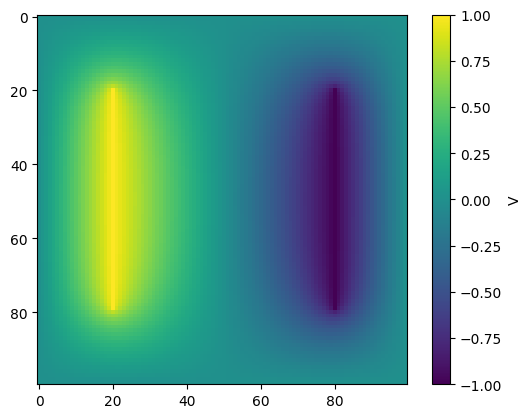

In [ ]:
#Type your code here
import numpy as np
import matplotlib.pyplot as plt

#Grid Parameters
N = 100
epsilon = 1e-6
# define grid spacing
a = 0.1/N # m

# Initialize Potential Array
solution = np.zeros([N,N],float)
# Start Initial Conditions!
solution[20:80, 20] = 1
solution[20:80, 80] = -1


def phi(i,j,V):
    return (V[j, i+1]+V[j,i-1]+V[j+1,i]+V[j-1,i])/4

# create logical convergence variable
converge = False

it = 0 # iteration counter
while converge == False:
    it += 1
    converge = True
    # calculate new solutions just on the interior points
    for j in range(1,N-1):
        for i in range(1,N-1):
            store = solution[j,i]
            solution[j,i] = phi(i,j,solution) # use the old solutions to calculate new solutions
            # Start Initial Conditions!
            solution[20:80, 20] = 1
            solution[20:80, 80] = -1
            if abs(solution[j,i]-store) > epsilon:
                converge = False

print ("Solution converged in {} iterations".format(it))
plt.imshow(solution)

plt.colorbar(label="V")
plt.show()

**Pts /5**

#### Exercise 1 Pts /15

## 2. Thermal diffusion in the Earth's crust : FTCS method

A classic example of a diffusion problem with a time-varying boundary condition is the diffusion of heat into the crust of the Earth, as surface temperature varies with the seasons.  Suppose the mean daily temperature at a particular point on the surface varies as:

\begin{equation*}
T_0(t) = A + B\sin {2\pi t\over\tau},
\end{equation*}

where $\tau=365\,$days, $A=10^\circ$C and $B=12^\circ$C.  At a depth of $20\,$m below the surface almost all annual temperature variation is ironed out and the temperature is, to a good approximation, a constant $11^\circ$C
(which is higher than the mean surface temperature of $10^\circ$C---temperature increases with depth, due to heating from the hot core of the planet).  The thermal diffusivity of the Earth's crust varies somewhat from place to place, but for our purposes we will treat it as constant with value $D=0.1\,\mathrm{m}^2\,\mathrm{day}^{-1}$.

Assume you calculate the temperature profile of the crust as a function of depth up to $20\,$m and time up to 10 years using the **FTCS method**.  

**a)** To use the FTCS method you have choose the number of spatial grid points M, and the number of time steps N. Show that your choices of M and N meet the condition of numerical stability.

The condition for numerical stability is:

$$
h \leq \frac{a^2}{2D}
$$

Note that $h$ is is the size of the time step, $a$ is is the spacing between grid points in the spacial dimension, and $D$ is the diffusion coefficient.


If we choose the number of spatial grid points M to be 100 and the number of time steps N to be 20000. Our parameters for $h$, $a$ become:

$$
Time = 10 \ years \cdot \frac{365 \ days}{1  \ year} = 3650 \ days
$$
$$
h = \frac{3650 \ days}{20000} = 0.1825 \ days
$$

and

$$
a = \frac{L}{M-1}
$$

With $L= 20$ m and $M = 1000$
$$
a = \frac{20}{100-1} \geq 0.2 \ m
$$

We have that:
$$
\frac{a^2}{2D} \geq \frac{0.2^2}{2 \cdot 0.1} = 0.2
$$

See that:
$$
h = 0.1825 \leq 0.2 \leq \frac{a^2}{2D}
$$
Therefore the condition is meet.





**Pts /5**

**b)** Now write a program to calculate the temperature profile of the crust as a function of depth up to $20\,$m and time up to 10 years using the **FTCS method**.  Start with temperature everywhere equal to $10^\circ$C, except at the surface and the deepest point, choose values for the number of grid points and the time-step $h$, then run your program
for the first nine simulated years, to allow it to settle down into whatever pattern it reaches.  Then for the tenth and final year plot four temperature profiles taken at 3-month intervals on a single graph to illustrate the seasonal temperature profiles.

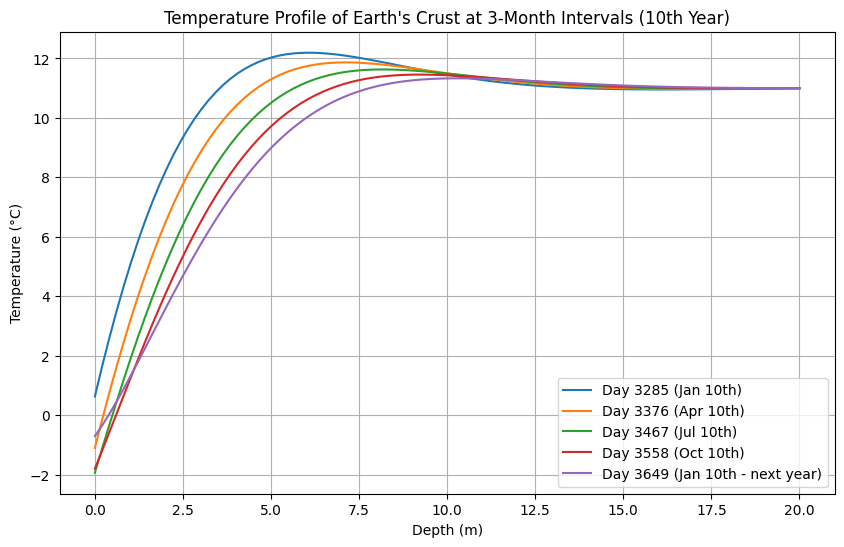

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Grid Parameters
M = 100
N = 20000
total_time = 3650 # days
depth = 20 # m
h = total_time/N
a = depth/(M-1)

# Parameter
D = 0.1

# Initialize Temperature Array
solution = np.zeros([M,N],float)
# Initial Boundary Condition

def surface_temp(t):
  return 10 + 12*np.sin(2 * np.pi * t / 365)

surface_temp = surface_temp(np.linspace(0,total_time, N))
lowest_level_tep = np.full([1, N], 11)
solution[0] = surface_temp
solution[M-1] = lowest_level_tep

# Initializing the starting matrix
solution[1:M-1, 0] = 11 # Changed M-2 to M-1 to initialize the full column correctly

for j in range(1, N):
  for i in range(1, M-1):
    solution[i, j] = solution[i, j-1] + h * D / (a**2) * (solution[i+1, j-1] + solution[i-1, j-1] - 2 * solution[i, j-1])

# 3 months is about 91 days, so we plot the last year we plot the last 3 month intervals.

depth_points = np.linspace(0, depth, M) # Create depth points for x-axis

plt.figure(figsize=(10, 6))
plt.plot(depth_points, solution[:,3285], label='Day 3285 (Jan 10th)')
plt.plot(depth_points, solution[:,3376], label='Day 3376 (Apr 10th)')
plt.plot(depth_points, solution[:,3467], label='Day 3467 (Jul 10th)')
plt.plot(depth_points, solution[:,3558], label='Day 3558 (Oct 10th)')
plt.plot(depth_points, solution[:,3649], label='Day 3649 (Jan 10th - next year)')

plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Profile of Earth\'s Crust at 3-Month Intervals (10th Year)')
plt.legend()
plt.grid(True)
plt.show()

**Pts /10**

#### Exercise 2 Pts /15

## Total HW Pts /30

AI use:
debugging
helping with plots!